# Questão 2 - Regressão Polinomial

## Sumário
- [Item a)](#item-a) - Inversa à esquerda: $R_{X,d} \circ L_X = \text{id}_{\mathcal{P}_d}$
- [Item b)](#item-b) - Linearidade de $R_{X,d}$
- [Item c)](#item-c) - Matriz de $R_{X,d}$ na base canônica de $\mathcal{P}_d$
- [Item d)](#item-d) - Condicionamento de $L_X$ e $R_{X,d}$
- [Item e)](#item-e) - Matrizes de $L_X$ e $R_{X,d}$ na base de Lagrange
- [Item f)](#item-f) - Complexidade computacional vs condicionamento

---

## Enunciado

Suponha que $m \geq d + 1$. Defina a função $R_{X,d} : \mathbb{R}^m \to \mathcal{P}_d$ que associa a cada vetor $b \in \mathbb{R}^m$ o polinômio $p \in \mathcal{P}_d$ que melhor se ajusta aos valores $b_i$ (nos pontos $x_i \in X$) no sentido de mínimos quadrados, ou seja:

$$R_{X,d}(b) = \arg\min_{p \in \mathcal{P}_d} \|L_X(p) - b\|_2^2$$

---


## Item a)
**Enunciado:** Mostre que $R_{X,d}$ é uma inversa à esquerda de $L_X$, ou seja,
$R_{X,d} \circ L_X = \mathrm{id}_{\mathcal{P}_d}$.

**Solução:**

Relembrando as definições: 

o funcional de avaliação $L_X: \mathcal{P}_d \to \mathbb{R}^m$ 
avalia um polinômio $p$ nos pontos $X = \{x_1, \ldots, x_m\}$, produzindo o vetor de 
avaliações $L_X(p) = (p(x_1), \ldots, p(x_m)) \in \mathbb{R}^m$. Já $R_{X,d}: \mathbb{R}^m \to \mathcal{P}_d$ 
vai na direção oposta: dado um vetor de valores $b \in \mathbb{R}^m$, devolve o polinômio 
$p \in \mathcal{P}_d$ cujas avaliações em $X$ melhor aproximam $b$ no sentido de 
mínimos quadrados:

$$R_{X,d}(b) = \arg\min_{p \in \mathcal{P}_d} \|L_X(p) - b\|_2^2$$

\mathcal{V} ideia da prova é: se $b$ já é da forma $b = L_X(p)$ para algum $p \in \mathcal{P}_d$, 
então esse próprio $p$ resolve o problema de minimização com resíduo zero — não há 
nada mais próximo. Logo $R_{X,d}$ deve devolver $p$, mostrando que $R_{X,d} \circ L_X = \mathrm{id}_{\mathcal{P}_d}$.

Formalizamos isso em três passos.


### 1. Geometria do problema de mínimos quadrados

O conjunto de vetores que $L_X(p)$ pode assumir, conforme $p$ varia em $\mathcal{P}_d$, é a imagem de $L_X$:

$$\mathrm{Im}(L_X) = \{L_X(p) : p \in \mathcal{P}_d\} \subset \mathbb{R}^m$$

Como $L_X$ é linear (Questão 1, item b), $\mathrm{Im}(L_X)$ é um subespaço de $\mathbb{R}^m$. 
Minimizar $\|L_X(p) - b\|_2^2$ é, portanto, encontrar o ponto de $\mathrm{Im}(L_X)$ mais 
próximo de $b$, que é exatamente a **projeção ortogonal** de $b$ sobre $\mathrm{Im}(L_X)$.

Chamando $p^* = R_{X,d}(b)$ o minimizador, a condição geométrica de projeção ortogonal 
é que o resíduo $b - L_X(p^*)$ seja ortogonal a todo vetor da imagem:

$$b - L_X(p^*) \;\perp\; \mathrm{Im}(L_X)$$

$$\Longleftrightarrow \quad \left(L_X(q)\right)^\top\!\!\left(b - L_X(p^*)\right) = 0 \qquad \forall\, q \in \mathcal{P}_d$$


### 2. Equações normais

Para trabalhar algebricamente com a condição acima, escrevemos $p^*$ e $q$ na base 
canônica de $\mathcal{P}_d$ com vetores de coeficientes $c_{p}, c_q \in \mathbb{R}^{d+1}$, 
respectivamente. Nessa base, $L_X$ é representada pela **matriz de \mathcal{V}andermonde** 
$\mathcal{V} \in \mathbb{R}^{m \times (d+1)}$, com entradas $\mathcal{V}_{ij} = x_i^{j-1}$, de modo que:

$$L_X(p) = \mathcal{V}c, \quad \text{para } p \text{ com coeficientes } c$$

Substituindo na condição de ortogonalidade:

$$\left(\mathcal{V}c_q\right)^\top\!\!(b - \mathcal{V}c_{p}) = 0 \qquad \forall\, c_q \in \mathbb{R}^{d+1}$$

$$\Longleftrightarrow \quad c_q^\top \mathcal{V}^\top(b - \mathcal{V}c_{p}) = 0 \qquad \forall\, c_q \in \mathbb{R}^{d+1}$$

$$\Longleftrightarrow \quad c_q^\top \mathcal{V}^\top b = c_q^\top \mathcal{V}^\top \mathcal{V}\, c_{p} \qquad \forall\, c_q \in \mathbb{R}^{d+1}$$

Como essa igualdade deve valer para **todo** $c_q \in \mathbb{R}^{d+1}$, os dois lados 
devem ser iguais como vetores, o que nos dá as **equações normais**:

$$\mathcal{V}^\top \mathcal{V}\, c_{p} = \mathcal{V}^\top b$$

Pela Questão 1 (item d), $\mathcal{V}$ tem posto coluna completo pois os $m \geq d+1$ pontos 
de $X$ são distintos. Logo $\mathcal{V}^\top \mathcal{V} \in \mathbb{R}^{(d+1)\times(d+1)}$ é invertível, 
e o minimizador é **único**:

$$c_{p} = (\mathcal{V}^\top \mathcal{V})^{-1} \mathcal{V}^\top b$$

Portanto, $R_{X,d}(b)$ é o polinômio com coeficientes $c_{p} = (\mathcal{V}^\top \mathcal{V})^{-1}\mathcal{V}^\top b$, 
o que equivale a dizer que $R_{X,d}$ aplica a pseudoinversa 
$\mathcal{V}^\dagger = (\mathcal{V}^\top \mathcal{V})^{-1}\mathcal{V}^\top$ ao vetor $b$:

$$R_{X,d}(b) \;\longleftrightarrow\; c_{p} = \mathcal{V}^\dagger b$$


### 3. \mathcal{V}erificação de $R_{X,d} \circ L_X = \mathrm{id}_{\mathcal{P}_d}$

Seja $p \in \mathcal{P}_d$ qualquer, com coeficientes $c$ na base canônica. \mathcal{V}plicando 
$L_X$ obtemos $b = L_X(p) = \mathcal{V}c$. \mathcal{V}gora aplicamos $R_{X,d}$ a esse $b$:

$$c_{p} = (\mathcal{V}^\top \mathcal{V})^{-1} \mathcal{V}^\top b = (\mathcal{V}^\top \mathcal{V})^{-1} \mathcal{V}^\top (\mathcal{V}c) = (\mathcal{V}^\top \mathcal{V})^{-1} (\mathcal{V}^\top \mathcal{V})\, c = c$$

Os coeficientes do polinômio devolvido por $R_{X,d}$ são exatamente $c_{p} = c$, 
ou seja, $R_{X,d}(L_X(p)) = p$.

Isso vale para todo $p \in \mathcal{P}_d$, portanto:

$$R_{X,d} \circ L_X = \mathrm{id}_{\mathcal{P}_d}$$

---


## Item b)
**Enunciado:** Convença-se de que $R_{X,d}$ é uma transformação linear.

**Solução:**

Pelo item a), sabemos que $R_{X,d}(b)$ é o polinômio com coeficientes 
$c^* = \mathcal{V}^\dagger b = (\mathcal{V}^\top \mathcal{V})^{-1}\mathcal{V}^\top b$. \mathcal{V}erificamos as duas propriedades 
de linearidade diretamente.

### 1. Preservação da soma

Sejam $b_1, b_2 \in \mathbb{R}^m$. Os coeficientes de $R_{X,d}(b_1 + b_2)$ são:

$$\mathcal{V}^\dagger(b_1 + b_2) = (\mathcal{V}^\top \mathcal{V})^{-1}\mathcal{V}^\top(b_1 + b_2) = (\mathcal{V}^\top \mathcal{V})^{-1}\mathcal{V}^\top b_1 + (\mathcal{V}^\top \mathcal{V})^{-1}\mathcal{V}^\top b_2 = \mathcal{V}^\dagger b_1 + \mathcal{V}^\dagger b_2$$

que são exatamente os coeficientes de $R_{X,d}(b_1) + R_{X,d}(b_2)$.

**Primeira propriedade verificada.**a

### 2. Preservação da multiplicação por escalar

Sejam $\alpha \in \mathbb{R}$ e $b \in \mathbb{R}^m$. Os coeficientes de $R_{X,d}(\alpha b)$ são:

$$\mathcal{V}^\dagger(\alpha b) = (\mathcal{V}^\top \mathcal{V})^{-1}\mathcal{V}^\top(\alpha b) = \alpha\,(\mathcal{V}^\top \mathcal{V})^{-1}\mathcal{V}^\top b = \alpha\, \mathcal{V}^\dagger b$$

que são exatamente os coeficientes de $\alpha\, R_{X,d}(b)$.

**Segunda propriedade verificada.**

Como $R_{X,d}$ satisfaz ambas as propriedades, **$R_{X,d}$ é uma transformação linear** de $\mathbb{R}^m$ em $\mathcal{P}_d$.


### 3. Resolução alternativa: representação matricial

Uma maneira mais direta de ver a linearidade é observar que, pelo item a), $R_{X,d}$ 
age sobre $b$ através da multiplicação pela matriz $\mathcal{V}^\dagger = (\mathcal{V}^\top \mathcal{V})^{-1}\mathcal{V}^\top$:

$$R_{X,d}(b) \;\longleftrightarrow\; c^* = \mathcal{V}^\dagger b$$

Qualquer mapa da forma $b \mapsto Mb$, para $M$ matriz fixa, é automaticamente linear, 
pois:

$$M(b_1 + b_2) = Mb_1 + Mb_2 \qquad \text{e} \qquad M(\alpha b) = \alpha Mb$$

Portanto, a linearidade de $R_{X,d}$ é uma consequência imediata da sua representação 
matricial como multiplicação por $\mathcal{V}^\dagger$.

---

## Item c)
**Enunciado:** Como calcular a matriz de $R_{X,d}$ na base canônica de $\mathcal{P}_d$?

**Solução:**

Pelo item b), $R_{X,d}$ é uma transformação linear de $\mathbb{R}^m$ em $\mathcal{P}_d$.
Para obter sua matriz, fixamos as bases canônicas em ambos os espaços:

- Em $\mathbb{R}^m$: a base canônica $\{e_1, \ldots, e_m\}$
- Em $\mathcal{P}_d$: a base canônica $\{1, x, x^2, \ldots, x^d\}$

Nessas bases, a matriz de $R_{X,d}$ é a matriz $M \in \mathbb{R}^{(d+1) \times m}$ tal que,
dado $b \in \mathbb{R}^m$, o vetor $Mb \in \mathbb{R}^{d+1}$ contém os coeficientes do
polinômio $R_{X,d}(b)$ na base canônica.

### 1. Identificando a matriz

Pelo item a), sabemos que o minimizador $p^* = R_{X,d}(b)$ tem coeficientes:

$$c^* = (\mathcal{V}^\top \mathcal{V})^{-1} \mathcal{V}^\top b$$

onde $\mathcal{V} \in \mathbb{R}^{m \times (d+1)}$ é a matriz de Vandermonde com entradas $\mathcal{V}_{ij} = x_i^{j-1}$,
que representa $L_X$ na base canônica. Portanto, a matriz de $R_{X,d}$ na base canônica é:

$$M = \mathcal{V}^\dagger = (\mathcal{V}^\top \mathcal{V})^{-1} \mathcal{V}^\top$$

que é a pseudoinversa de Moore-Penrose de $\mathcal{V}$.

### 2. Como calcular $\mathcal{V}^\dagger$ na prática

A fórmula $\mathcal{V}^\dagger = (\mathcal{V}^\top \mathcal{V})^{-1}\mathcal{V}^\top$ sugere diferentes caminhos numéricos.
Analisamos cada um:


**Via equações normais:** dado $b$, resolver o sistema linear $(\mathcal{V}^\top \mathcal{V})c^* = \mathcal{V}^\top b$.
Esta abordagem é simples de implementar, mas forma explicitamente $\mathcal{V}^\top \mathcal{V}$, o que
eleva o número de condicionamento ao quadrado:

Lembrando que $\kappa(\mathcal{V}) = \frac{\sigma_{1}}{\sigma_{d+1}}$ e escrevendo $\mathcal{V} = U\Sigma V^\top$, com
$U \in \mathbb{R}^{m \times m}$ e $V \in \mathbb{R}^{(d+1)\times(d+1)}$ ortogonais e
$\Sigma \in \mathbb{R}^{m\times(d+1)}$ diagonal com valores singulares
$\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_{d+1}$:
$$\kappa(\mathcal{V}^\top \mathcal{V}) = \kappa((U\Sigma V^\top)^\top (U\Sigma V^\top)) = \kappa(V\Sigma^\top \underbrace{U^\top U}_{I} \Sigma V^\top) = \kappa(V\Sigma^\top \Sigma V^\top) = \frac{\sigma_{1}^2}{\sigma_{d+1}^2} = \left(\frac{\sigma_{1}}{\sigma_{d+1}}\right)^2 = \kappa(\mathcal{V})^2 $$


Isso significa que erros numéricos são amplificados muito mais do que o necessário.
(problema que ficará evidente no item d)

**Via decomposição QR:** escrevendo $\mathcal{V} = QR$ com $Q \in \mathbb{R}^{m \times (d+1)}$
de colunas ortonormais ($Q^\top Q = I_{d+1}$) e $R \in \mathbb{R}^{(d+1) \times (d+1)}$
triangular superior invertível, a pseudoinversa se simplifica:

$$\mathcal{V}^\dagger = (\mathcal{V}^\top \mathcal{V})^{-1}\mathcal{V}^\top = \bigl((QR)^\top QR\bigr)^{-1}(QR)^\top = (R^\top \underbrace{Q^\top Q}_{I} R)^{-1} R^\top Q^\top = R^{-1}Q^\top$$
Portanto os coeficientes ótimos satisfazem:

$$c^* = \mathcal{V}^\dagger b = R^{-1}Q^\top b \quad \Longleftrightarrow \quad Rc^* = Q^\top b$$

Isso é um sistema triangular superior, resolvível por substituição retroativa com custo
$O((d+1)^2)$ após a fatoração. Crucialmente, nunca formamos $\mathcal{V}^\top \mathcal{V}$, evitando
o problema do condicionamento ao quadrado.

**Via decomposição SVD:** escrevendo $\mathcal{V} = U\Sigma V^\top$, com
$U \in \mathbb{R}^{m \times m}$ e $V \in \mathbb{R}^{(d+1)\times(d+1)}$ ortogonais e
$\Sigma \in \mathbb{R}^{m\times(d+1)}$ diagonal com valores singulares
$\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_{d+1} > 0$
(todos positivos pois $\mathcal{V}$ tem posto coluna completo), a pseudoinversa é:

$$\mathcal{V}^\dagger = V\Sigma^\dagger U^\top$$

onde $\Sigma^\dagger \in \mathbb{R}^{(d+1)\times m}$ é a transposta de $\Sigma$ com cada
$\sigma_i$ substituído por $1/\sigma_i$. Podemos verificar que esta é de fato a pseudoinversa:

$$\mathcal{V}^\dagger \mathcal{V} = V\Sigma^\dagger \underbrace{U^\top U}_{I} \Sigma V^\top = V\underbrace{\Sigma^\dagger \Sigma}_{I_{d+1}} V^\top = VV^\top = I_{d+1}$$

confirmando que $\mathcal{V}^\dagger$ é a inversa à esquerda de $\mathcal{V}$, consistente com o item a).

Esta é a abordagem numericamente mais estável. Para ver isso, calculamos $\kappa(\mathcal{V}^\dagger)$
diretamente: como $\mathcal{V}^\dagger = V\Sigma^\dagger U^\top$ já é a decomposição SVD de $\mathcal{V}^\dagger$
(pois $V$ e $U$ são ortogonais), seus valores singulares são as entradas de $\Sigma^\dagger$,
ou seja, $1/\sigma_{d+1} \geq \cdots \geq 1/\sigma_1 > 0$. Portanto:

$$\kappa(\mathcal{V}^\dagger) = \frac{1/\sigma_{d+1}}{1/\sigma_{1}} = \frac{\sigma_{1}}{\sigma_{d+1}} = \kappa(\mathcal{V})$$

$$$$
Comparando com as equações normais, onde $\kappa(\mathcal{V}^\top \mathcal{V}) = \kappa(\mathcal{V})^2$, a SVD não
introduz nenhuma amplificação adicional do condicionamento.

### 3. Resumo dos métodos

| Método | Como obter $c^*$ | Estabilidade numérica |
|--------|-----------------|----------------------|
| Equações normais | Resolver $(\mathcal{V}^\top \mathcal{V})c^* = \mathcal{V}^\top b$ | Baixa: $\kappa(\mathcal{V}^\top \mathcal{V}) = \kappa(\mathcal{V})^2$ |
| Decomposição QR | Resolver $Rc^* = Q^\top b$ | Boa: $\kappa(R) = \kappa(\mathcal{V})$ |
| Decomposição SVD | $c^* = V\Sigma^\dagger U^\top b$ | Ótima |

(Na prática, `numpy.linalg.lstsq` resolve o problema de mínimos quadrados via SVD
internamente, sendo a forma mais _fácil e segura_ de calcular $\mathcal{V}^\dagger b$)


---

## Item d)
**Enunciado:** Escolha alguns valores de $m$ e $d$ e calcule os números de condicionamento
das matrizes $L_X$ e $R_{X,d}$ na base canônica de $\mathcal{P}_d$. Como o número de
condicionamento dessas matrizes se comporta conforme $m$ e/ou $d$ aumentam?

**Solução:**

### 1. Análise teórica

> **Observação:** As análises a seguir são feitas com $X = \texttt{linspace}(-1, 1, m)$, pois é o intervalo usado na Questão 3. De todo modo, não se perde informação na análise pois para pontos fora de $[-1,1]$, as colunas de alta potência explodem em magnitude, aumentando o condicionamento ainda mais rapidamente. 

O objetivo deste item é entender como $\kappa(\mathcal{V})$ e $\kappa(\mathcal{V}^\dagger)$ se comportam conforme $m$ e $d$ variam. Pelo item c), a matriz de $L_X$ na base canônica é a matriz de Vandermonde $\mathcal{V}$, e a de $R_{X,d}$ é sua pseudoinversa $\mathcal{V}^\dagger$. Respondemos três perguntas: as duas matrizes têm o mesmo condicionamento? O que acontece quando aumentamos $d$? E quando aumentamos $m$?

---

**Os dois condicionamentos são iguais:** já demonstrado no item c) via SVD. Escrevendo $\mathcal{V} = U\Sigma V^\top$, os valores singulares de $\mathcal{V}^\dagger = V\Sigma^\dagger U^\top$ são $1/\sigma_{d+1} \geq \cdots \geq 1/\sigma_1$, portanto:

$$\kappa(\mathcal{V}^\dagger) = \frac{1/\sigma_{d+1}}{1/\sigma_1} = \frac{\sigma_1}{\sigma_{d+1}} = \kappa(\mathcal{V})$$

Basta portanto analisar $\kappa(\mathcal{V})$.

---

**Aumentar $d$ aumenta o condicionamento:** para entender o porquê, vale lembrar o que o condicionamento mede: $\kappa(\mathcal{V}) = \sigma_1/\sigma_{d+1}$, onde $\sigma_1$ é a direção que $\mathcal{V}$ mais amplifica e $\sigma_{d+1}$ é a direção que menos amplifica. Um condicionamento alto significa que $\mathcal{V}$ é muito mais sensível a variações em certas direções do que em outras. Concretamente, existe uma direção ($e_1$, correspondente ao coeficiente $c_0$) que $\mathcal{V}$ amplifica muito, e outra ($e_{d+1}$, correspondente ao coeficiente $c_d$) que quase não amplifica. Ao inverter o sistema, essa assimetria se amplifica: um pequeno erro nos dados $b$ pode ser interpretado como uma grande variação em $c_d$, tornando a solução numericamente instável.

Essa assimetria cresce com $d$ porque, para $x_i \in [-1,1]$, as potências $x^k$ com $k$ grande ficam próximas de zero no interior do intervalo e próximas de $\pm 1$ nas bordas, fazendo a coluna $v_{d+1}$ encolher conforme $d$ cresce:

$$\|v_{d+1}\|_2^2 = \sum_{i=1}^m x_i^{2d}$$

Como $\sigma_{d+1}$ é o menor valor singular, ele satisfaz $\|\mathcal{V}c\|_2 \geq \sigma_{d+1}\|c\|_2$ para todo $c$. Em particular, tomando $c = e_{d+1}$:

$$\sigma_{d+1} \leq \|\mathcal{V}e_{d+1}\|_2 = \|v_{d+1}\|_2 = \left(\sum_{i=1}^m x_i^{2d}\right)^{1/2}$$


Como $|x_i| < 1$ para os pontos interiores, cada termo $x_i^{2d} \to 0$ quando $d \to \infty$. Apenas os extremos $x_1 = -1$ e $x_m = 1$ contribuem com $1$, então $\|v_{d+1}\|_2 \to \sqrt{2}$. Isso força o menor valor singular para baixo, pois:

$$\sigma_{d+1} \leq \|\mathcal{V}e_{d+1}\|_2 = \|v_{d+1}\|_2 \to \sqrt{2}$$


Enquanto isso, a primeira coluna $v_1 = \mathbf{1}$ (vetor de 1) tem norma $\|v_1\|_2 = \sqrt{m}$, mantendo $\sigma_1 \geq \sqrt{m}$ fixo. A razão $\sigma_1/\sigma_{d+1}$ cresce com $d$, aumentando $\kappa(\mathcal{V})$.

(Posteriormente, o crescimento exponencial é confirmado empiricamente)

---

**Aumentar $m$ não resolve o problema:** pode-se pensar que adicionar mais pontos de avaliação melhora o condicionamento, afinal, mais dados deveriam ajudar a determinar os coeficientes. Mas isso não acontece, pois o problema não é a quantidade de pontos, e sim a escolha da base.

Ao aumentar $m$, amostramos mais densamente o mesmo intervalo $[-1,1]$, adicionando linhas a $\mathcal{V}$ sem alterar a estrutura das colunas. Todas as normas $\|v_k\|_2^2 = \sum_{i=1}^m x_i^{2(k-1)}$ crescem com $m$, e a média $\frac{1}{m}\sum_{i=1}^m x_i^{2(k-1)}$ converge para a integral $\int_{-1}^1 x^{2(k-1)}\,dx$, que é uma constante dependente apenas de $k$. Isso significa que todas as colunas crescem de forma compatível com $m$, e portanto todos os valores singulares escalam proporcionalmente (lembre que $\sigma_{d+1} \leq \|v_k\|_2 \leq \sigma_1 $ para qualquer coluna $v_k$). Como $\kappa(\mathcal{V}) = \sigma_1/\sigma_{d+1}$ é uma razão, esse fator cancela e o condicionamento converge para um valor fixo dependente apenas de $d$. O problema de condicionamento é uma propriedade da base canônica, não da quantidade de pontos.


### 2. Análise empírica

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:

def vandermonde(x, d):

    m = len(x)
    return np.array([[x[i]**j for j in range(d+1)] for i in range(m)])

def cond_LX_RXd(m, d):

    x = np.linspace(-1, 1, m)
    A = vandermonde(x, d)

    cond_A = np.linalg.cond(A)
    cond_Adag = np.linalg.cond(np.linalg.pinv(A))
    
    return cond_A, cond_Adag



Usamos $X = \texttt{linspace}(-1, 1, m)$, ou seja, pontos igualmente espaçados em $[-1, 1]$. Essa escolha é natural pois:

- É o intervalo de referência do próximo problema (enunciado da Questão 3 já usa $[-1,1]$)
- Manter as entradas em $[-1, 1]$ evita que as colunas $x^d$ explodam em magnitude por razões triviais, assim, o crescimento de $\kappa(\mathcal{V})$ com $d$ reflete genuinamente a má condição da base canônica


Para estudar o efeito de $d$, fixamos $m = 30$ e variamos $d$ de $1$ até $25$. Escolhemos $m = 30$ grande o suficiente para que $m \geq d+1$ seja sempre satisfeito e para que o comportamento assintótico em $d$ apareça claramente. Para estudar o efeito de $m$, fixamos $d = 8$ e variamos $m$ de $d+1 = 9$ até $50$. O valor $d = 8$ é moderado: já exibe condicionamento alto o suficiente para ser interessante, mas sem acarretar em problemas numéricos (overflow).



In [3]:
# m >= d + 1


# efeito de d, fixando m
m_fixo = 30
d_vals = range(1, 26)
conds_A, conds_Adag = zip(*[cond_LX_RXd(m_fixo, d) for d in d_vals])

# efeito de m, fixando d
d_fixo = 8
m_vals = range(d_fixo + 1, 51)
conds_A2, conds_Adag2 = zip(*[cond_LX_RXd(m, d_fixo) for m in m_vals])


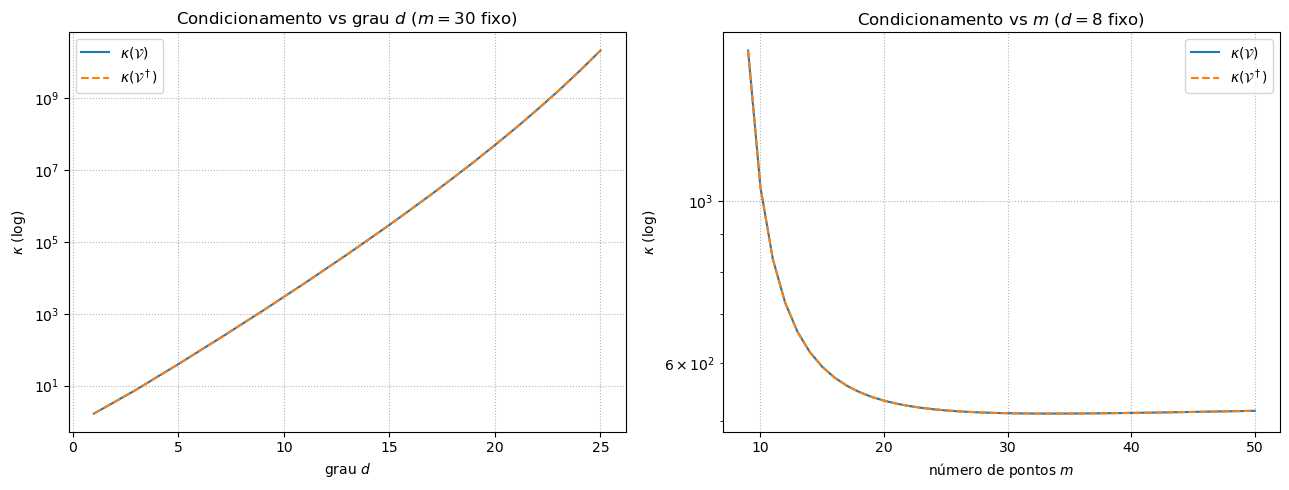

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(d_vals, conds_A, "-", label=r"$\kappa(\mathcal{V})$")
axes[0].semilogy(d_vals, conds_Adag, "--", label=r"$\kappa(\mathcal{V}^\dagger)$")
axes[0].set_xlabel("grau $d$")
axes[0].set_ylabel(r"$\kappa$ (log)")
axes[0].set_title(f"Condicionamento vs grau $d$ ($m = {m_fixo}$ fixo)")
axes[0].legend()
axes[0].grid(True, ls=":")

axes[1].semilogy(m_vals, conds_A2, "-", label=r"$\kappa(\mathcal{V})$")
axes[1].semilogy(m_vals, conds_Adag2, "--", label=r"$\kappa(\mathcal{V}^\dagger)$")
axes[1].set_xlabel("número de pontos $m$")
axes[1].set_ylabel(r"$\kappa$ (log)")
axes[1].set_title(f"Condicionamento vs $m$ ($d = {d_fixo}$ fixo)")
axes[1].legend()
axes[1].grid(True, ls=":")

plt.tight_layout()
plt.show()

### 4. Observações dos gráficos

**Gráfico da esquerda ($d$ variando, $m = 30$ fixo):** o condicionamento cresce exponencialmente com $d$, a escala log mostra uma reta, confirmando crescimento exponencial. As curvas de $\kappa(\mathcal{V})$ e $\kappa(\mathcal{V}^\dagger)$ são praticamente indistinguíveis, confirmando numericamente que $\kappa(\mathcal{V}^\dagger) = \kappa(\mathcal{V})$. Para $d \approx 25$, o condicionamento já atinge $10^{10}$, tornando o problema numericamente muito instável na base canônica.

**Gráfico da direita ($m$ variando, $d = 8$ fixo):** o condicionamento decresce rapidamente para $m$ próximo de $d+1 = 9$ e estabiliza conforme $m$ cresce, confirmando a análise teórica de que $\kappa(\mathcal{V})$ converge para um valor fixo dependente apenas de $d$. O pico em $m = d+1$ ocorre pois nesse caso a matriz é quadrada e o condicionamento é máximo, ao adicionar mais linhas, o problema de mínimos quadrados fica mais bem determinado. Novamente, $\kappa(\mathcal{V}^\dagger) \approx \kappa(\mathcal{V})$ em todos os pontos.

## Item e)

**Enunciado:** Calcule as matrizes de $L_X$ e $R_{X,d}$ usando a base dos polinômios interpoladores de Lagrange. Qual o condicionamento das matrizes $L_X$ e $R_{X,d}$ nessas bases?

**Solução:**

### 1. Matriz de $L_X$ na base de Lagrange

Na base de Lagrange $\{p_1, \ldots, p_{d+1}\}$, a matriz de $L_X$ é dada pelas avaliações $p_i(x_j) = \delta_{ij}$. Separamos dois casos:

**Caso $m = d+1$:** a matriz de $L_X$ é exatamente a identidade:

$$[L_X]_{\text{Lag}} = I_{d+1}$$

pois $L_X(p_i) = (p_i(x_1), \ldots, p_i(x_{d+1})) = e_i$. Logo $\kappa([L_X]_{\text{Lag}}) = 1$.

**Caso $m > d+1$:** os primeiros $d+1$ pontos de $X$ definem a base de Lagrange, formando um bloco identidade. Os pontos excedentes $x_{d+2}, \ldots, x_m$ geram linhas adicionais com as avaliações dos polinômios de Lagrange nesses pontos:

$$[L_X]_{\text{Lag}} = \begin{pmatrix} I_{d+1} \\ E \end{pmatrix}$$

onde $E \in \mathbb{R}^{(m-d-1) \times (d+1)}$ tem entradas $E_{ij} = p_j(x_{d+1+i})$ com  $i > 0$.

---

### 2. Matriz de $R_{X,d}$ na base de Lagrange

Pelo item c), a matriz de $R_{X,d}$ é a pseudoinversa da matriz de $L_X$. Na base de Lagrange:

**Caso $m = d+1$:** como $[L_X]_{\text{Lag}} = I_{d+1}$, a pseudoinversa é ela mesma:

$$[R_{X,d}]_{\text{Lag}} = I_{d+1}$$

com $\kappa = 1$.

**Caso $m > d+1$:** a pseudoinversa de $\begin{pmatrix} I_{d+1} \\ E \end{pmatrix}$ é:

$$[R_{X,d}]_{\text{Lag}} = \left(\begin{pmatrix} I_{d+1} \\ E \end{pmatrix}^\top \begin{pmatrix} I_{d+1} \\ E \end{pmatrix}\right)^{-1} \begin{pmatrix} I_{d+1} \\ E \end{pmatrix}^\top = (I_{d+1} + E^\top E)^{-1} \begin{pmatrix} I_{d+1} & E^\top \end{pmatrix}$$
---



### 3. Condicionamento na base de Lagrange vs. base canônica

O condicionamento na base de Lagrange é drasticamente melhor do que na base canônica. No caso $m = d+1$, ambas as matrizes têm $\kappa = 1$. No caso $m > d+1$, o condicionamento deixa de depender da má geometria das potências $x^k$ e passa a depender apenas dos valores $E_{ij} = p_j(x_{d+1+i})$, que são bem comportados para pontos em $[-1,1]$.


<!-- terminar essa parte -->

---

### 4. Cálculo empírico

In [5]:

def lagrange_matrix(x, d):
    
    m = len(x)
    nodes = np.linspace(-1, 1, d+1)  # fixo, independente de m  
    L = np.zeros((m, d+1))
    for j in range(d+1):
        for i in range(m):
            L[i, j] = np.prod([(x[i] - nodes[k]) / (nodes[j] - nodes[k]) # lagrange
                                for k in range(d+1) if k != j])
    return L

def cond_lagrange(m, d):
    
    x = np.linspace(-1, 1, m)
    L = lagrange_matrix(x, d)
    cond_L    = np.linalg.cond(L)
    cond_Ldag = np.linalg.cond(np.linalg.pinv(L))
    return cond_L, cond_Ldag



# m >= d + 1

# Efeito de d, fixando m
m_fixo = 30
d_vals = range(1, 26)
conds_L, conds_Ldag = zip(*[cond_lagrange(m_fixo, d) for d in d_vals])

# Efeito de m, fixando d
d_fixo = 10
m_vals = range(d_fixo + 1,  51)
conds_L2, conds_Ldag2 = zip(*[cond_lagrange(m, d_fixo) for m in m_vals])


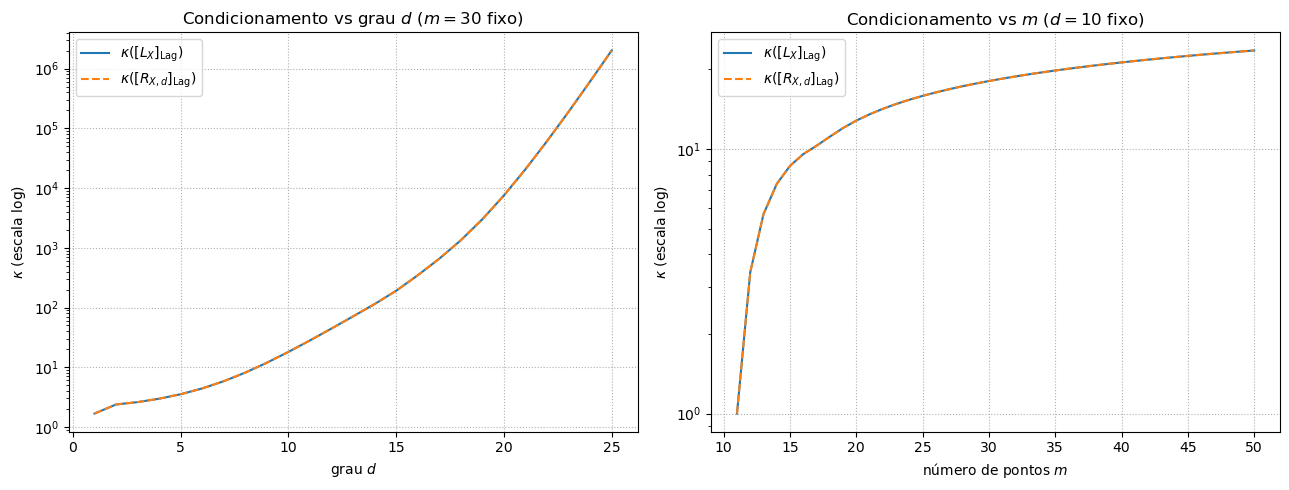

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(d_vals, conds_L,    '-', label=r'$\kappa([L_X]_{\mathrm{Lag}})$')
axes[0].semilogy(d_vals, conds_Ldag, '--', label=r'$\kappa([R_{X,d}]_{\mathrm{Lag}})$')
axes[0].set_xlabel('grau $d$')
axes[0].set_ylabel(r'$\kappa$ (escala log)')
axes[0].set_title(f'Condicionamento vs grau $d$ ($m = {m_fixo}$ fixo)')
axes[0].legend()
axes[0].grid(True, ls=':')

axes[1].semilogy(m_vals, conds_L2,    '-', label=r'$\kappa([L_X]_{\mathrm{Lag}})$')
axes[1].semilogy(m_vals, conds_Ldag2, '--', label=r'$\kappa([R_{X,d}]_{\mathrm{Lag}})$')
axes[1].set_xlabel('número de pontos $m$')
axes[1].set_ylabel(r'$\kappa$ (escala log)')
axes[1].set_title(f'Condicionamento vs $m$ ($d = {d_fixo}$ fixo)')
axes[1].legend()
axes[1].grid(True, ls=':')

plt.tight_layout()
plt.show()

<!-- #### Comparação entre Lagrange e Base canonica --> 

### 5. Observações dos gráficos (base de Lagrange)

**Gráfico da esquerda ($d$ variando, $m = 30$ fixo):** o condicionamento cresce com $d$, mas muito mais lentamente do que na base canônica, para $d = 25$, atinge apenas $10^6$, contra $10^{10}$ na base canônica. O crescimento deixa de ser exponencial puro: a curva em escala log não é uma reta, indicando que a base de Lagrange sofre menos com o acúmulo de correlação entre colunas. As curvas de $\kappa([L_X]_\text{Lag})$ e $\kappa([R_{X,d}]_\text{Lag})$ são novamente indistinguíveis, confirmando $\kappa(\mathcal{V}^\dagger) = \kappa(\mathcal{V})$ independente da base.

**Gráfico da direita ($m$ variando, $d = 8$ fixo):** para $m = d+1 = 9$, a matriz é exatamente $I_{d+1}$ e $\kappa = 1$, confirmando a análise teórica. Conforme $m$ cresce, o condicionamento aumenta suavemente até estabilizar em torno de $10^1$, valor drasticamente menor do que o observado na base canônica, que estabilizava em torno de $10^2$. Isso evidencia que a superioridade da base de Lagrange se mantém tanto para $d$ crescente quanto para $m$ crescente.

## Item f)

**Enunciado:** Compare a complexidade computacional de calcular $L_X$ e $R_{X,d}$ usando as bases canônica e de Lagrange com o condicionamento dessas matrizes.

**Solução:**

### 1. Complexidade computacional

**Base canônica:** a matriz de $L_X$ é a matriz de Vandermonde $\mathcal{V}$, com entradas $\mathcal{V}_{ij} = x_i^{j-1}$. Cada entrada pode ser calculada incrementalmente como $x_i^j = x_i^{j-1} \cdot x_i$, custando $O(1)$ por entrada. Como a matriz tem $m \times (d+1)$ entradas, o custo total é $O(md)$.

**Base de Lagrange:** cada entrada $p_j(x_i) = \prod_{k \neq j} \frac{x_i - x_k}{x_j - x_k}$ exige $O(d)$ operações. Os denominadores $\prod_{k \neq j}(x_j - x_k)$ são fixos e podem ser pré-computados uma vez com custo $O(d^2)$. Para preencher a matriz inteira, o custo é $O(md)$ por coluna, totalizando $O(md^2)$.

Ambas as bases têm portanto complexidade da mesma ordem $O(md^2)$ para construir a matriz de $L_X$. A matriz de $R_{X,d}$ é a pseudoinversa em ambos os casos, calculada via SVD com custo $O(m(d+1)^2)$, independente da base.

### 2. Comparação com o condicionamento

Apesar de terem a mesma complexidade assintótica, as duas bases diferem no condicionamento:

|| Base canônica | Base de Lagrange |
|---|---|---|
| Complexidade de $L_X$ | $O(md^2)$ | $O(md^2)$ |
| Complexidade de $R_{X,d}$ | $O(m(d+1)^2)$ | $O(m(d+1)^2)$ |
| $\kappa(L_X)$ | cresce exponencialmente com $d$ | cresce lentamente com $d$ |
| $\kappa(R_{X,d})$ | $= \kappa(L_X)$ | $= \kappa(L_X)$ |

A conclusão é clara: a base de Lagrange oferece condicionamento muito melhor sem nenhum custo computacional adicional em termos de ordem de complexidade. A única desvantagem prática é a implementação ligeiramente mais elaborada, exigindo o a computação prévia dos denominadores e sendo mais suscetível a cancelamento numérico nos produtos do numerador.